## Plot the distributions of precipitation in the MPI-ESM1.2-LR data to find out if log(pr) is useful.

In [1]:
# Import modules
# Data visualization
import matplotlib.pyplot as plt

# Data manipulation
import pandas as pd
import numpy as np
import xarray as xr

# for debugging, but might actually not be used in code
import glob
from pathlib import Path
from tqdm.notebook import tqdm
from dask.diagnostics import ProgressBar
from emcli2.dataset.interim_to_processed import calculate_global_weighted_average
import keras

import emcli2
import importlib
importlib.reload(emcli2)

import os
os.environ["KERAS_BACKEND"] = "torch"

2024-07-30 14:11:26.904305: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-07-30 14:11:26.951526: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-30 14:11:27.886892: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [ ]:
repo_root = '../'
# data_root = '/mnt/c/Users/Bjoern/data/climate-emulator/'
data_root = '/d3/lutjens/bc3/data/'
data_path = data_root + 'raw/CMIP6/MPI-ESM1-2-LR/' # raw data downloaded from CMIPX
data_path_interim = data_root + 'interim/CMIP6/MPI-ESM1-2-LR/' # interim data, such as, statistical summaries

scenarios_train = ['historical', 'ssp126','ssp370','ssp585'] # 1pctCO2, picontrol, hist-aer, hist-GHG, abrupt-4xCO2
scenarios_test = ['ssp245']
scenarios_aux = []

from emcli2.dataset.mpi_esm1_2_lr import get_meta

slider = 10
data_var = 'pr'
meta = get_meta(data_path, data_path_interim)
len_historical = 165


In [3]:
from emcli2.dataset.mpi_esm1_2_lr import get_filepaths_mpi_esm1_2_lr
from emcli2.dataset.mpi_esm1_2_lr import load_mpi_data_as_xr
# Get climatology:

scenarios = scenarios_train + scenarios_test + scenarios_aux
assert 'historical' in scenarios, 'historical scenario must be included in scenarios'

# Load precomputed ensemble summaries for runtime increase.
df = get_filepaths_mpi_esm1_2_lr(data_var=data_var,
        scenarios=scenarios,
        data_path=data_path_interim,
        filename_wildcard='ensemble.nc',
        frequency=meta[data_var]['frequency'],
        verbose=False)

datasets, climatology = load_mpi_data_as_xr(df=df, meta=meta, 
                climatology=None, m_member_subset=None,
                open_data_parallel=True)


If next line throws segmentation fault, try changing config.open_data_parallel to False.
[########################################] | 100% Completed | 1.62 sms


In [4]:
from emcli2.dataset.mpi_esm1_2_lr import create_train_splits

Y_train_mpi, Y_test_mpi, Y_aux_mpi = create_train_splits(datasets, data_var=data_var,
                                            scenarios_train=scenarios_train,
                                            scenarios_test=scenarios_test,
                                            scenarios_aux=scenarios_aux,
                                            verbose=True)

Y_mpi_tas = Y_train_mpi[0:2] + [Y_test_mpi[0].sel(time=slice('2015',None))] + Y_train_mpi[2:]
Y_mpi_tas[2].attrs['experiment_id'] = 'ssp245'
scenarios =  scenarios_train[0:2] + scenarios_test + scenarios_train[2:]
colors = ['tab:blue', 'tab:green', 'black', 'tab:orange', 'tab:red', 'tab:purple']



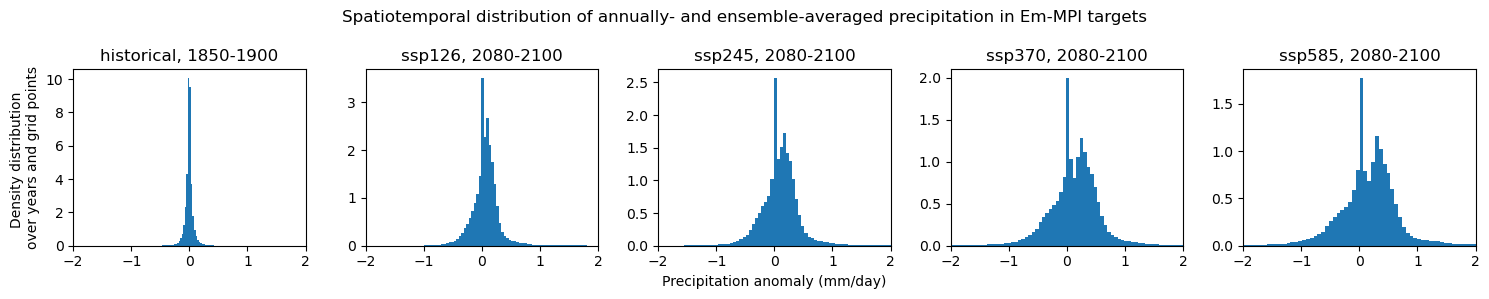

In [6]:
timeframes = [slice('1850', '1900')] + 4*[slice('2080','2100')] # slice('1850','1900') # 
add_gaussian = False

fig, axs = plt.subplots(1, 5, figsize=(5*3,1*3), dpi=100)
for scenario_id, scenario  in enumerate(scenarios):
    timeframe = timeframes[scenario_id]
    var_local = Y_mpi_tas[scenario_id][data_var].sel(time=timeframe)

    var_ens_avg = var_local.mean(dim='member').values.flatten()
    # bin_weights=np.ones(len(var_ens_avg)) / len(var_ens_avg)
    # axs[scenario_id].hist(var_ens_avg, density=False, weights=bin_weights, bins=100) # weights=bin_weights, bins=50, density=True)  # arguments are passed to np.histogram
    axs[scenario_id].hist(var_ens_avg, density=True, bins=100) # weights=bin_weights, bins=50, density=True)  # arguments are passed to np.histogram

    # Add best Gaussian fit
    if add_gaussian:
        non_nan = var_local.mean(dim='member').values.flatten() # var_region.values[~np.isnan(var_region.values)].flatten()
        mean = non_nan.mean()
        std = non_nan.std()
        xvals = np.linspace(mean-4*std, mean+4*std, 200)
        pdf = stats.norm.pdf(xvals, mean, std)
        axs[scenario_id].plot(xvals, pdf, color='black', alpha=0.5, linewidth=2)

    # axs[scenario_id].set_ylim(0, 1.)
    axs[scenario_id].set_xlim(-2.,2.)
    axs[scenario_id].set_title(f"{scenario}, {timeframe.start}-{timeframe.stop}")
    if scenario_id == 0:
        axs[scenario_id].set_ylabel("Density distribution \nover years and grid points")
    if scenario_id == len(scenarios) // 2:
        axs[scenario_id].set_xlabel("Precipitation anomaly (mm/day)")

    var_local.close(); del var_local
fig.suptitle(f"Spatiotemporal distribution of annually- and ensemble-averaged precipitation in Em-MPI targets")
plt.tight_layout()

filepath_to_save = repo_root + f'docs/figures/mpi-esm1-2-lr/{data_var}/distribution/over_loc_and_year.png'
Path(filepath_to_save).parent.mkdir(parents=True, exist_ok=True)
plt.savefig(filepath_to_save)

plt.show()
plt.close()

In [95]:
import regionmask
import cartopy.crs as ccrs

# region_names=['Greenland/Iceland']
region_names = ['Greenland/Iceland', 'Russian-Arctic', 'E.North-America', 'S.Central-America','N.Europe','Sahara','E.Asia', 'S.E.Asia', 'W.Antarctica','Equatorial.Pacific-Ocean','Southern-Ocean']
region_names = ['Greenland/Iceland', 'S.Central-America','N.Europe', 'S.Eastern-Africa', 'S.E.Asia']

# Select a scenario and timeframe
scenario = 'historical' # 'historical', 'ssp245'
scenario_id = scenarios.index(scenario)
timeframe = slice('1850','1900') # slice('2080','2100') # slice('1850','1900') # 
var_local = Y_mpi_tas[scenario_id][data_var].sel(time=timeframe)

# Get region information from IPCC AR6 regions
ar6_all = regionmask.defined_regions.ar6.all
region = ar6_all[region_names]
region_idxs = list(region.regions.keys())

# Create global weighted average
try:
    var_local = var_local.rename({'longitude': 'lon','latitude': 'lat'}) # regionmask assumes lat,lon keys
except:
    pass
weights = np.cos(np.deg2rad(var_local.lat))

# Create regional weighted average
mask_3D = ar6_all.mask_3D(var_local) # mask with region information
var_regional = var_local.weighted(mask_3D * weights).mean(dim=("lat", "lon"))
years = var_regional.time.dt.year

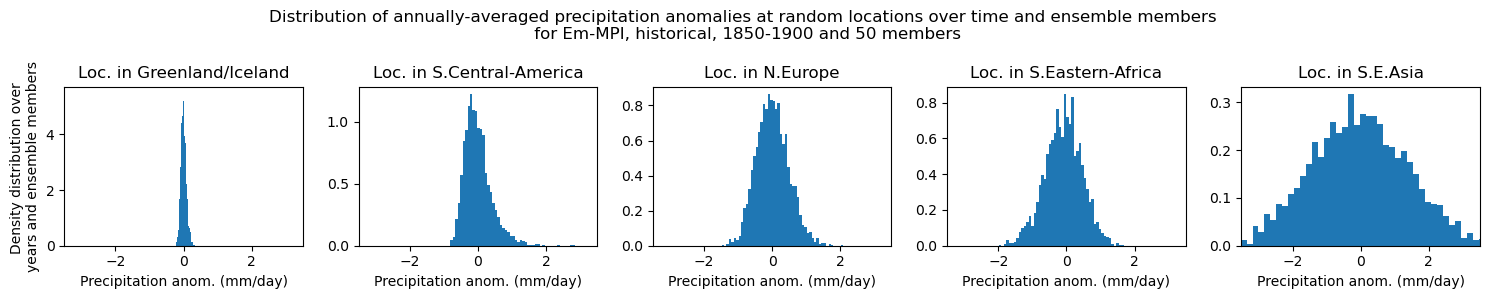

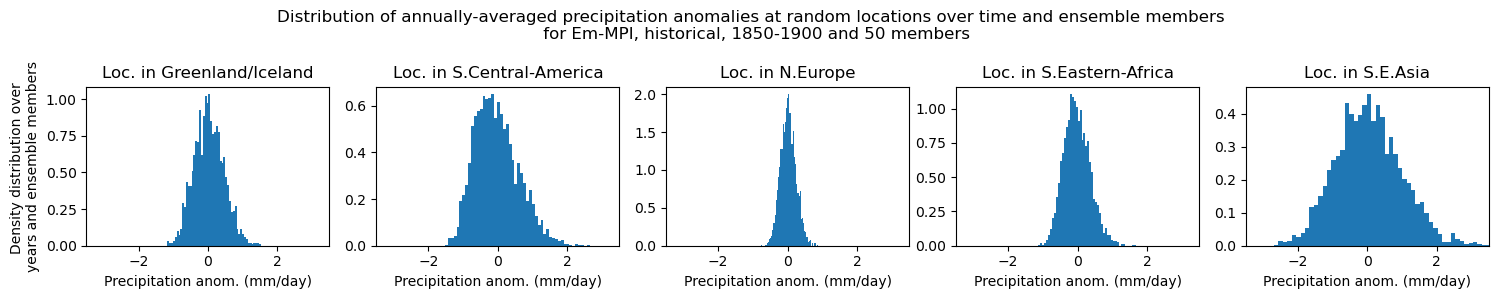

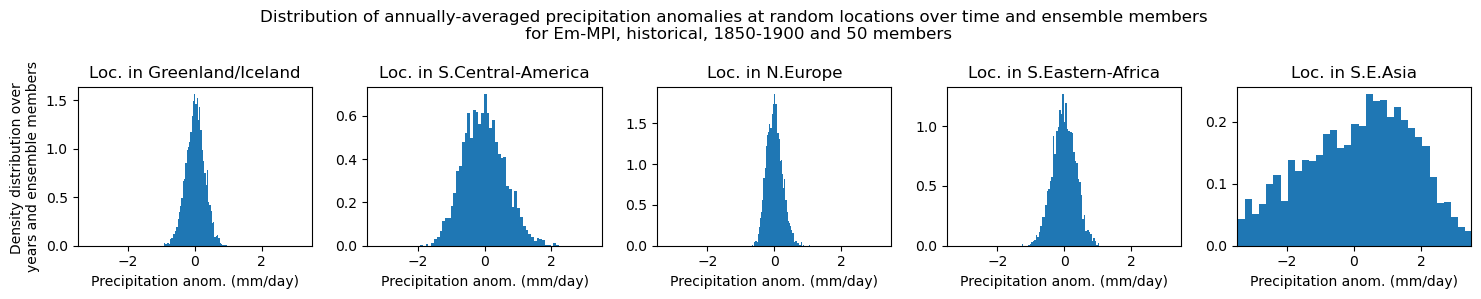

In [102]:
import math

from scipy import stats

n_plots = 3 # Number of times to repeat plotting the data (e.g., plotting random location each time.)
add_gaussian=False
n_cols = 5
n_rows = math.ceil(len(region_idxs)/n_cols)

for plt_idx in range(n_plots):
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols*3,n_rows*3), dpi=100)
    if axs.ndim == 1:
        axs = axs.reshape(1,-1)
    
    for iter, region_idx in enumerate(region_idxs):
        # Get rol and column id from iter
        row_id = iter // n_cols
        col_id = iter % n_cols

        # Average over region
        #main_label = f'{ar6_all[region_idx].name}'
        #var_region = var_regional.sel(region=region_idx)
        # fig.suptitle(f"Em-MPI {data_var} anom.\n over {scenario}, {timeframe.start}-{timeframe.stop} and {len(var_region.member)} members")
        # filename = 'over_yr_and_mem'
        # n_bins = 150

        # Keep all values in region
        #main_label = f'{ar6_all[region_idx].name}'
        #mask = ar6_all.mask(var_local)
        #var_region = var_local.where(mask.cf == ar6_all[region_idx].abbrev)
        #fig.suptitle(f"Distribution of annually-averaged precipitation anomalies over time, locations in region, and ensemble members \n for Em-MPI, {scenario}, {timeframe.start}-{timeframe.stop} and {len(var_region.member)} members")
        #filename = 'over_yr_member_and_loc_in_region'
        #if row_id == n_rows//2 and col_id == 0:
        #    axs[row_id, col_id].set_ylabel("Density distribution over years,\nlocations, and ensemble members")
        #axs[row_id, col_id].set_title(main_label)
        #axs[row_id, col_id].set_xlim(-3.5,3.5)
        # n_bins = 150

        # Pick random grid point across globe
        #rand_lat = np.random.choice(var_local.lat.values)
        #rand_lon = np.random.choice(var_local.lon.values)
        #main_label = f'lat: {rand_lat:.2f}, lon: {rand_lon:.2f}'
        #var_region = var_local.sel(lat=rand_lat, lon=rand_lon)
        #fig.suptitle(f"Distribution of annually-averaged precipitation anomalies at random locations over time and ensemble members \n for Em-MPI, {scenario}, {timeframe.start}-{timeframe.stop} and {len(var_region.member)} members")
        #filename = 'over_yr_and_mem_in_random_location'
        #if row_id == n_rows//2 and col_id == 0:
        #    axs[row_id, col_id].set_ylabel("Density distribution over years and ensemble members")
        #axs[row_id, col_id].set_title(main_label)
        #axs[row_id, col_id].set_xlim(-3.5,3.5)
        #n_bins = 20

        # Pick random location within region
        # Retrieve the index of a random location within region mask
        main_label = f'Loc. in {ar6_all[region_idx].name}'
        mask = ar6_all.mask(var_local)
        mask_region = mask.cf == ar6_all[region_idx].abbrev
        true_indices = np.argwhere(mask_region.values) # dim (n_indices, 2)
        random_location_idx = true_indices[np.random.randint(true_indices.shape[0])]
        # Create a new mask that is all zeroes except for the random location
        new_mask = xr.zeros_like(mask_region, dtype=bool)
        new_mask[random_location_idx[0], random_location_idx[1]] = True
        var_region = var_local.where(new_mask)
        fig.suptitle(f"Distribution of annually-averaged precipitation anomalies at random locations over time and ensemble members \n for Em-MPI, {scenario}, {timeframe.start}-{timeframe.stop} and {len(var_region.member)} members")
        filename = f'over_yr_member_and_loc_in_random_location_{plt_idx}'
        if row_id == n_rows//2 and col_id == 0:
            axs[row_id, col_id].set_ylabel("Density distribution over \nyears and ensemble members")
        axs[row_id, col_id].set_title(main_label)
        axs[row_id, col_id].set_xlim(-3.5,3.5)
        n_bins = 50

        axs[row_id, col_id].hist(var_region.values.flatten(), density=True, bins=n_bins)#, label=main_label)  # arguments are passed to np.histogram
        # axs[row_id, col_id].set_title(f"{main_label}")

        # Add best Gaussian fit
        if add_gaussian:
            non_nan = var_region.values[~np.isnan(var_region.values)].flatten()
            mean = non_nan.mean()
            std = non_nan.std()
            xvals = np.linspace(mean-4*std, mean+4*std, 200)
            pdf = stats.norm.pdf(xvals, mean, std)
            axs[row_id,col_id].plot(xvals, pdf, color='black', alpha=0.5, linewidth=2)

        if row_id >= n_rows-1:
            axs[row_id, col_id].set_xlabel("Precipitation anom. (mm/day)")
        # axs[row_id, col_id].legend(loc='upper right')

    # Set super title
    plt.tight_layout()

    filepath_to_save = repo_root + f'docs/figures/mpi-esm1-2-lr/{data_var}/distribution/{scenario}_{filename}.png'
    Path(filepath_to_save).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(filepath_to_save)

    plt.show()
    plt.close()

In [61]:
var_local.where(new_mask)

<xarray.DataArray 'pr' (member: 50, time: 21, lat: 96, lon: 192)>
array([[[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
...
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]]])
Coordinates:
  * lat      (lat) float64 -88.57 -86.72 -84.86 -83.0 ... 83.0 84.86 86.72 88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * time     (time) datetime64[ns] 2080-12-31 2081-12-31 ... 2100-12-31
Dimensions without coordinates: member
Attributes:
    standard_name:  precipitation_flux
    long_name:      Precipitation
    comment:        includes both liquid and solid phases
    units:          mm/day
    original_name:  pr
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    _ChunkSizes:    [  1  96 192]
    title:          Precipitation, "pr", in mm/day

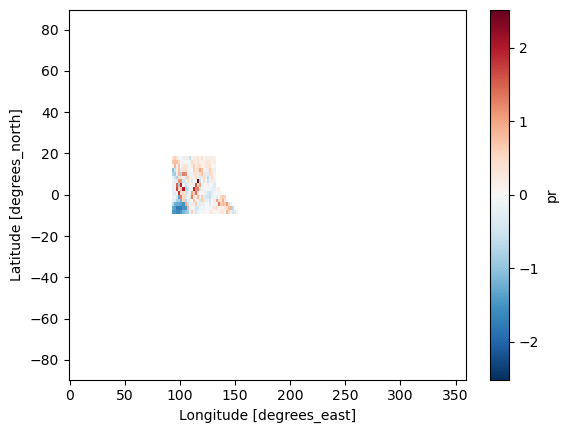

In [14]:
var_region.mean(dim='member').mean(dim='time').plot()

In [ ]:
var_region.values.flatten()

array([nan, nan, nan, ..., nan, nan, nan])

# Archive

In [ ]:
mask = ar6_all.mask(var_local)
var_GIC = var_local.where(mask.cf == "GIC")

proj = ccrs.NorthPolarStereo()
ax = plt.subplot(111, projection=proj)
ax.set_global()

var_GIC.isel(member=1).isel(time=1).plot.pcolormesh(
    ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree()
)

# add region border
ar6_all[["GIC"]].plot(
    ax=ax, add_coastlines=False, label="abbrev"
)

ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
ax.coastlines();

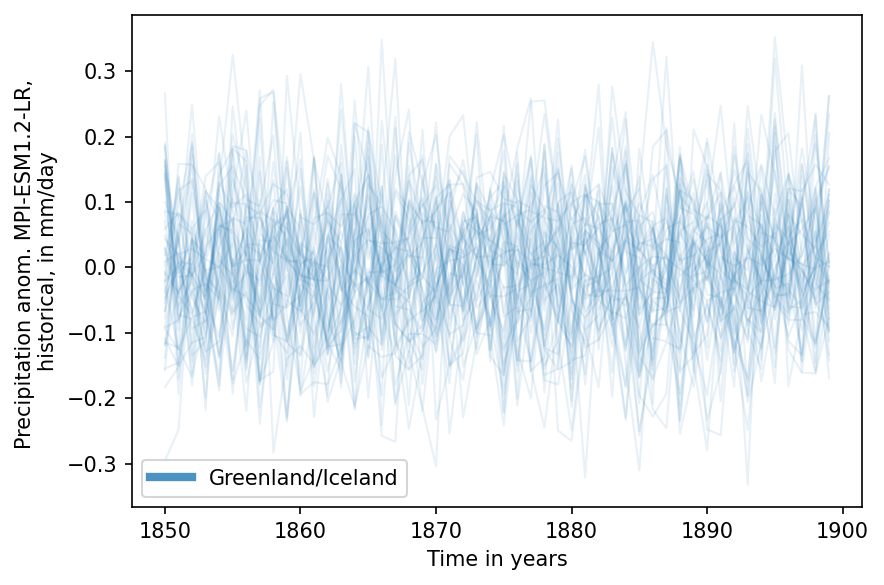

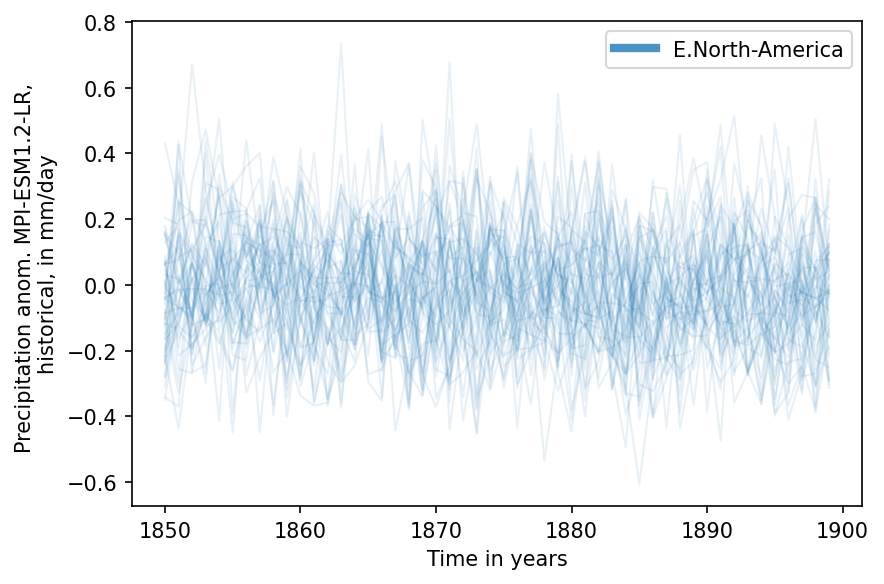

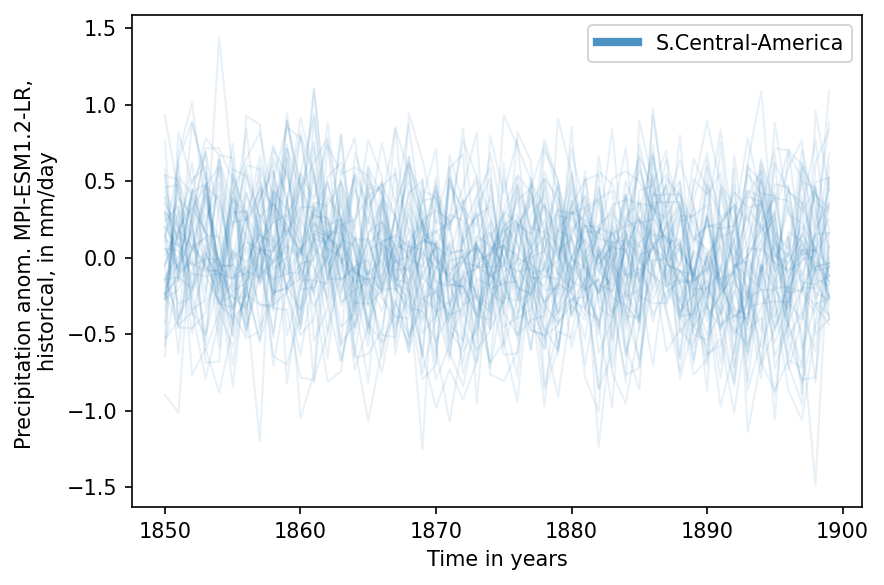

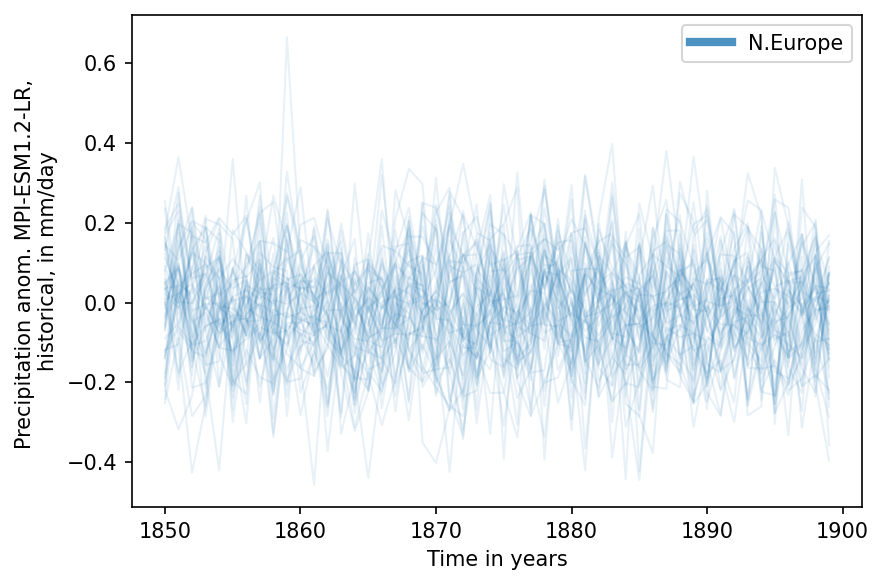

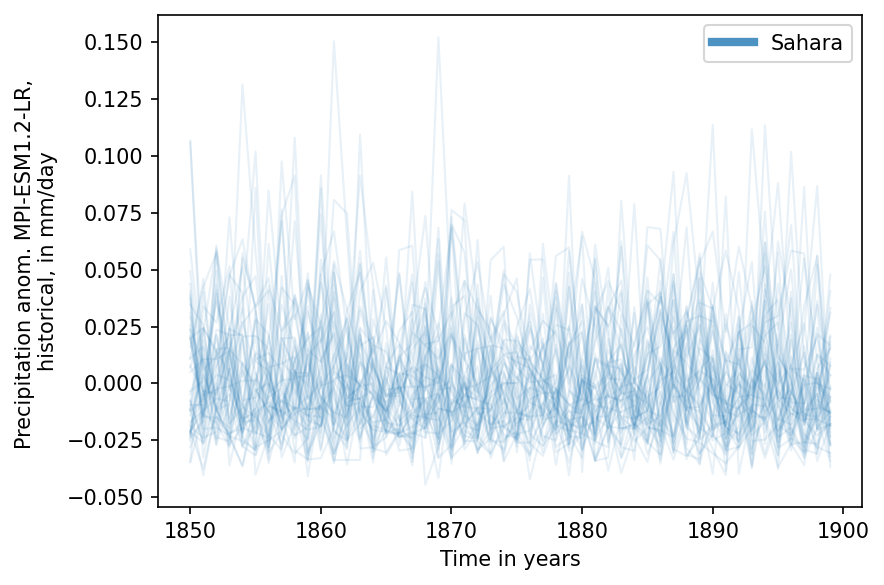

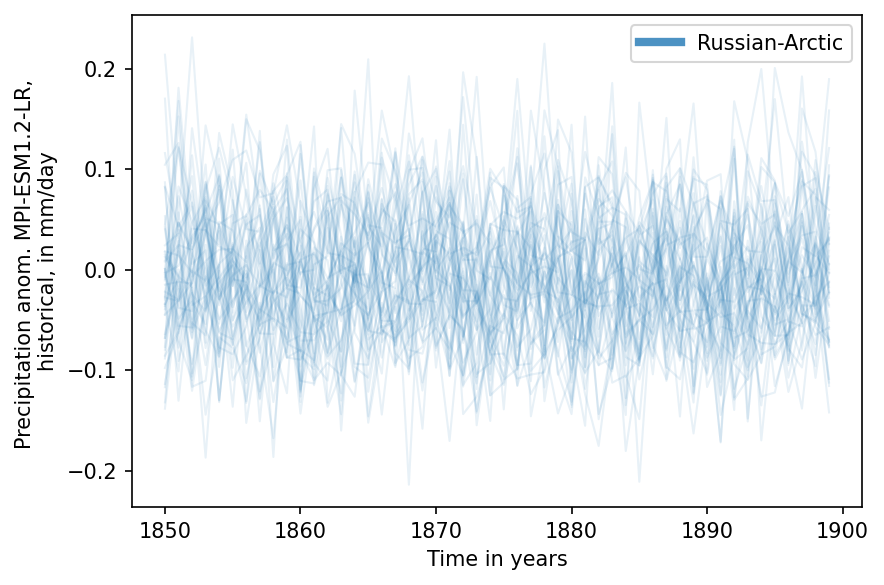

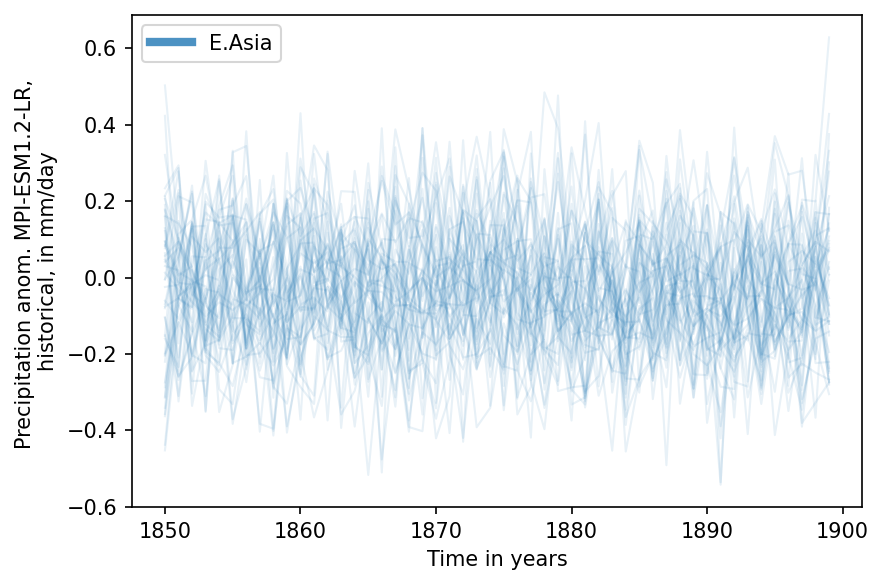

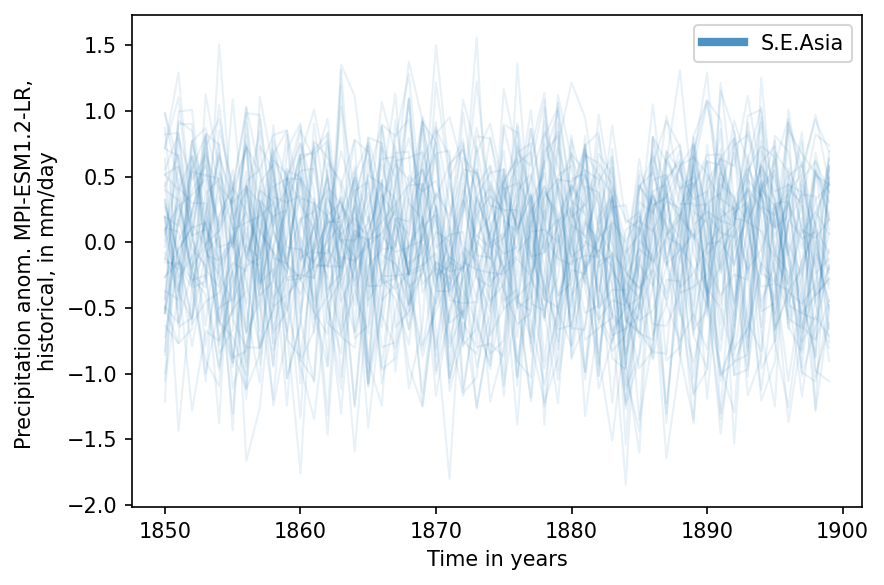

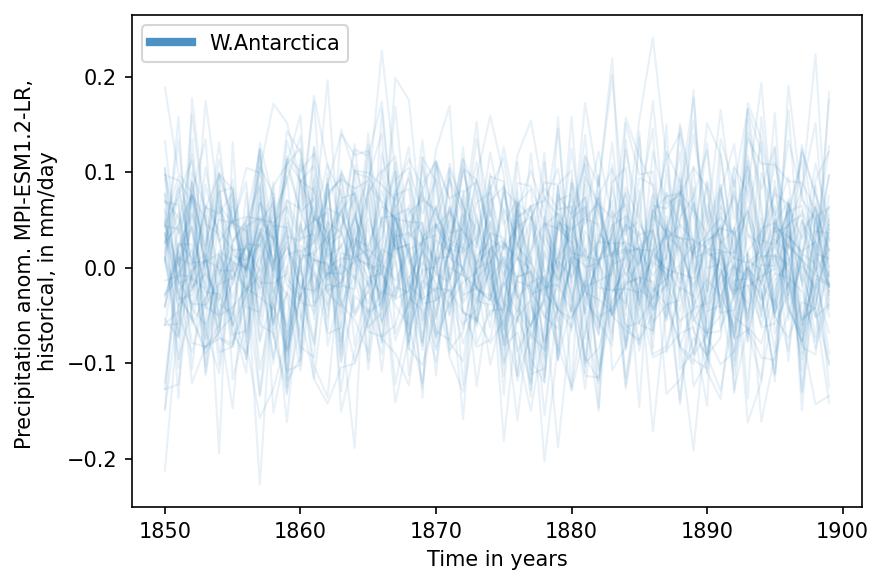

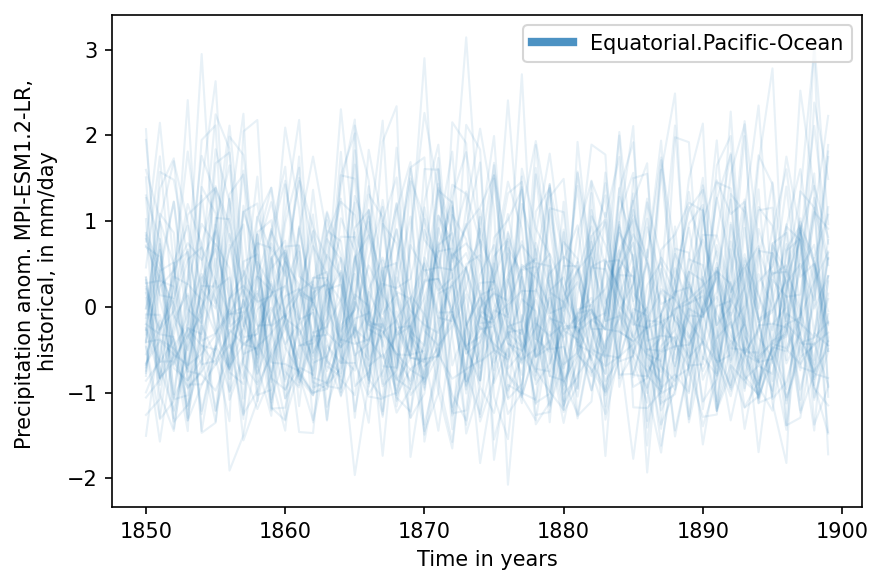

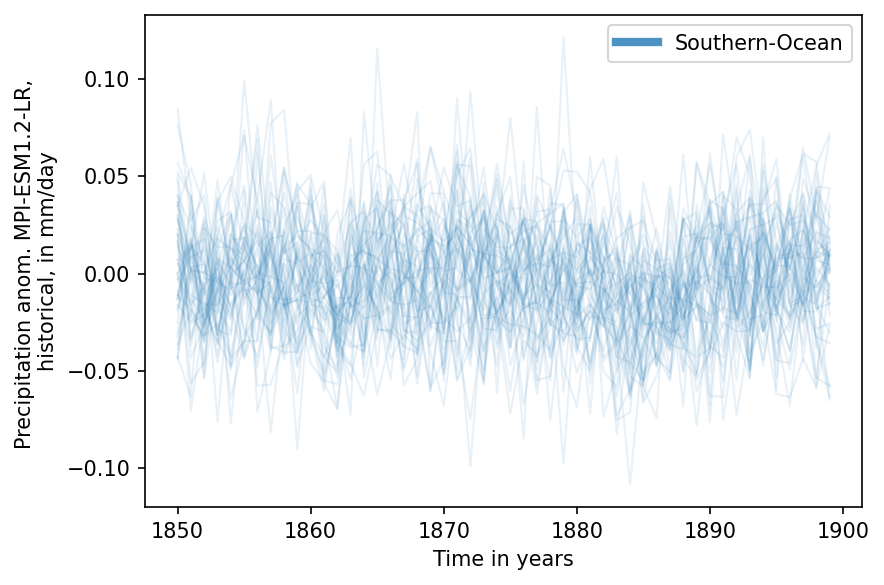

In [ ]:
# region_idx = region_idxs[0]
for row_id, region_idx in enumerate(region_idxs):
    main_label = f'{ar6_all[region_idx].name}'
    var_region = var_regional.sel(region=region_idx)
    
    # Plot spaghetti.
    fig, axs = plt.subplots(1, 1, figsize=(6,4), dpi=150)
    for m in var_region.member:
        linewidth = 1. # 1 if m==0 else 0.5
        var_member = var_region[var_region.member == m][0]
        axs.plot(var_member.time.dt.year,var_member, alpha=0.1, linewidth=linewidth,color=colors[0], label=main_label)# , label=data.attrs['experiment_id'])
        if m==0:
            leg = axs.legend()

        var_member.close(); del var_member
    axs.set_xlabel('Time in years')
    axs.set_ylabel('Precipitation anom. MPI-ESM1.2-LR, \nhistorical, in mm/day')
    for legobj in leg.legend_handles:
        legobj.set_linewidth(4.0)
        legobj.set_alpha(0.8)
    plt.tight_layout()
    plt.show()
    plt.close()

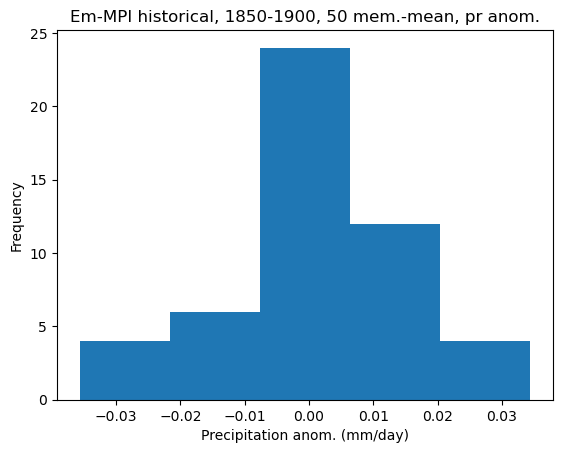

In [ ]:
plt.hist(var_region.mean(dim='member').values.flatten(), bins=5)  # arguments are passed to np.histogram
plt.title(f"Em-MPI historical, 1850-1900, 50 mem.-mean, {data_var} anom.")
plt.ylabel("Frequency")
plt.xlabel("Precipitation anom. (mm/day)")
plt.show()

If next line throws segmentation fault, try changing config.open_data_parallel to False.
[########################################] | 100% Completed | 1.53 sms
Frozen({'time': 165, 'longitude': 144, 'latitude': 96}) historical
Frozen({'time': 86, 'longitude': 144, 'latitude': 96}) ssp126
Frozen({'time': 86, 'longitude': 144, 'latitude': 96}) ssp370
Frozen({'time': 86, 'longitude': 144, 'latitude': 96}) ssp585
Data statistics before normalization:
CO2:	 mean: 2375.1560986597005 	 std:  2375.1560986597005
SO2:	 mean: 2.9337515374160833e-12 	 std:  2.9337515374160833e-12
CH4:	 mean: 0.3187776319853236 	 std:  0.3187776319853236
BC:	 mean: 2.070624691735028e-13 	 std:  2.070624691735028e-13
Frozen({'time': 251, 'longitude': 144, 'latitude': 96}) ssp245
Data statistics before normalization:
CO2:	 mean: 2375.1560986597005 	 std:  2375.1560986597005
SO2:	 mean: 2.9337515374160833e-12 	 std:  2.9337515374160833e-12
CH4:	 mean: 0.3187776319853236 	 std:  0.3187776319853236
BC:	 mean: 2.07062469